In [ ]:
"""
PINN Slab Waveguide Solver — 1D (v2)
=====================================
Solves the 1D Helmholtz eigenvalue equation for a slab waveguide:
    d²E/dx² + k0² n(x)² E = β² E

Key improvements over v1:
  - Symmetry enforcement (even-mode hard constraint)
  - Interface-focused + Gaussian collocation sampling
  - Beta initialised from analytical transcendental equation
  - Xavier weight initialisation
  - Cosine annealing LR scheduler
  - Gradient clipping
  - Best-weights checkpointing

Result: n_eff error reduced from ~0.5% (v1) to ~0.01% (v2)
"""

'\nPINN Slab Waveguide Solver — 1D (v2)\n=====================================\nSolves the 1D Helmholtz eigenvalue equation for a slab waveguide:\n    d²E/dx² + k0² n(x)² E = β² E\n \nKey improvements over v1:\n  - Symmetry enforcement (even-mode hard constraint)\n  - Interface-focused + Gaussian collocation sampling\n  - Beta initialised from analytical transcendental equation\n  - Xavier weight initialisation\n  - Cosine annealing LR scheduler\n  - Gradient clipping\n  - Best-weights checkpointing\n \nResult: n_eff error reduced from ~0.5% (v1) to ~0.01% (v2)\n'

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

torch.manual_seed(42)
np.random.seed(42)

In [ ]:
# ─────────────────────────────────────────────
# PHYSICAL PARAMETERS
# ─────────────────────────────────────────────
lambda0 = 1.55          # µm (telecom C-band)
k0      = 2 * np.pi / lambda0
n_core  = 1.50
n_clad  = 1.45
d       = 2.0           # core full width (µm)
a       = d / 2         # core half-width

x_min, x_max = -6.0, 6.0

V = k0 * a * np.sqrt(n_core**2 - n_clad**2)
print(f"V-number = {V:.4f}  ({'single' if V < np.pi/2 else 'multi'}-mode regime)")

V-number = 1.5568  (single-mode regime)


In [ ]:
# ─────────────────────────────────────────────
# ANALYTICAL SOLUTION (Transcendental Equation)
# ─────────────────────────────────────────────

def transcendental_TE(n_eff, mode_order=0):
    if n_eff <= n_clad or n_eff >= n_core:
        return np.nan
    kappa = k0 * np.sqrt(n_core**2 - n_eff**2)
    gamma = k0 * np.sqrt(n_eff**2 - n_clad**2)
    if mode_order % 2 == 0:
        return kappa * np.tan(kappa * a) - gamma
    else:
        return -kappa / np.tan(kappa * a) - gamma

n_scan = np.linspace(n_clad + 1e-6, n_core - 1e-6, 50000)
f_vals = [transcendental_TE(n) for n in n_scan]
sign_changes = np.where(np.diff(np.sign(f_vals)))[0]
n_anal = brentq(transcendental_TE, n_scan[sign_changes[0]],
                n_scan[sign_changes[0] + 1], xtol=1e-10)
print(f"Analytical n_eff (exact) = {n_anal:.8f}")

def analytical_field(x_arr):
    kappa = k0 * np.sqrt(n_core**2 - n_anal**2)
    gamma = k0 * np.sqrt(n_anal**2 - n_clad**2)
    E = np.zeros_like(x_arr)
    inside  = np.abs(x_arr) <= a
    outside = ~inside
    E[inside]  = np.cos(kappa * x_arr[inside])
    E[outside] = np.cos(kappa * a) * np.exp(-gamma * (np.abs(x_arr[outside]) - a))
    dx   = x_arr[1] - x_arr[0]
    norm = np.sqrt(np.sum(E**2) * dx)
    return E / norm

Analytical n_eff (exact) = 1.48233894


In [ ]:
# ─────────────────────────────────────────────
# REFRACTIVE INDEX
# ─────────────────────────────────────────────

def refractive_index(x):
    return torch.where(torch.abs(x) <= a,
                       torch.tensor(n_core, dtype=torch.float32),
                       torch.tensor(n_clad, dtype=torch.float32))

In [ ]:
# ─────────────────────────────────────────────
# PINN MODEL
# ─────────────────────────────────────────────

class PINN1D(nn.Module):
    def __init__(self, beta_init):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1)
        )
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_normal_(layer.weight)

        self.beta = nn.Parameter(torch.tensor([beta_init]))

    def forward(self, x):
        # Hard-enforce even symmetry: E(x) = E(-x)
        return (self.net(x) + self.net(-x)) / 2

In [ ]:
# ─────────────────────────────────────────────
# COLLOCATION POINTS
# ─────────────────────────────────────────────

x_bulk   = np.random.uniform(x_min, x_max, (1500, 1))
x_iface  = np.vstack([
    np.random.uniform(-a - 0.2, -a + 0.2, (300, 1)),
    np.random.uniform( a - 0.2,  a + 0.2, (300, 1))
])
x_gauss  = np.vstack([
    np.random.normal(-a, 0.05, (100, 1)),
    np.random.normal( a, 0.05, (100, 1))
])
x_all    = np.clip(np.vstack([x_bulk, x_iface, x_gauss]), x_min, x_max)
x_train  = torch.tensor(x_all, dtype=torch.float32, requires_grad=True)
x_bc     = torch.tensor([[x_min], [x_max]], dtype=torch.float32)

In [ ]:
# ─────────────────────────────────────────────
# TRAINING
# ─────────────────────────────────────────────

beta_init = k0 * n_anal * 0.98
model     = PINN1D(beta_init)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=1500, eta_min=1e-5)

loss_hist = []
best_loss = float('inf')
best_state = None

print("\nTraining...")
for ep in range(1500):
    optimizer.zero_grad()

    E   = model(x_train)
    dE  = torch.autograd.grad(E, x_train, grad_outputs=torch.ones_like(E),
                               create_graph=True)[0]
    d2E = torch.autograd.grad(dE, x_train, grad_outputs=torch.ones_like(dE),
                               create_graph=True)[0]

    n   = refractive_index(x_train)
    res = d2E + (k0**2) * (n**2) * E - (model.beta**2) * E

    loss_phys = torch.mean(res**2)
    loss_bc   = torch.mean(model(x_bc)**2)
    loss_norm = (torch.mean(E**2) - 1.0)**2

    loss = loss_phys + 20.0 * loss_bc + 2.0 * loss_norm
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()

    loss_hist.append(loss.item())
    if loss.item() < best_loss:
        best_loss  = loss.item()
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    if ep % 300 == 0:
        print(f"  Epoch {ep:4d} | Loss: {loss.item():.4e} | n_eff: {model.beta.item()/k0:.8f}")

model.load_state_dict(best_state)


Training...
  Epoch    0 | Loss: 5.5741e+00 | n_eff: 1.45293879
  Epoch  300 | Loss: 2.0955e-01 | n_eff: 1.48247936
  Epoch  600 | Loss: 9.6976e-02 | n_eff: 1.48253676
  Epoch  900 | Loss: 5.7086e-02 | n_eff: 1.48242019
  Epoch 1200 | Loss: 4.8178e-02 | n_eff: 1.48237502


<All keys matched successfully>

In [ ]:
# ─────────────────────────────────────────────
# RESULTS
# ─────────────────────────────────────────────

n_pinn = model.beta.item() / k0
error  = abs(n_pinn - n_anal) / n_anal * 100

print(f"\n{'='*45}")
print(f"  PINN  n_eff = {n_pinn:.8f}")
print(f"  Exact n_eff = {n_anal:.8f}")
print(f"  Error       = {error:.5f}%")
print(f"{'='*45}")


  PINN  n_eff = 1.48237137
  Exact n_eff = 1.48233894
  Error       = 0.00219%


In [ ]:
# ─────────────────────────────────────────────
# EVALUATION
# ─────────────────────────────────────────────

x_test_np = np.linspace(x_min, x_max, 800).reshape(-1, 1)
x_test_t  = torch.tensor(x_test_np, dtype=torch.float32)
dx        = x_test_np[1, 0] - x_test_np[0, 0]

with torch.no_grad():
    E_pred = model(x_test_t).numpy().flatten()
E_pred /= np.sqrt(np.sum(E_pred**2) * dx)

E_anal = analytical_field(x_test_np.flatten())
if np.dot(E_pred, E_anal) < 0:
    E_pred = -E_pred

# Physics residual on test grid
x_res_t = torch.tensor(x_test_np, dtype=torch.float32, requires_grad=True)
E_r     = model(x_res_t)
dE_r    = torch.autograd.grad(E_r, x_res_t, torch.ones_like(E_r), create_graph=True)[0]
d2E_r   = torch.autograd.grad(dE_r, x_res_t, torch.ones_like(dE_r), create_graph=True)[0]
n_r     = refractive_index(x_res_t)
res_np  = (d2E_r + (k0**2) * (n_r**2) * E_r - (model.beta**2) * E_r).detach().numpy().flatten()

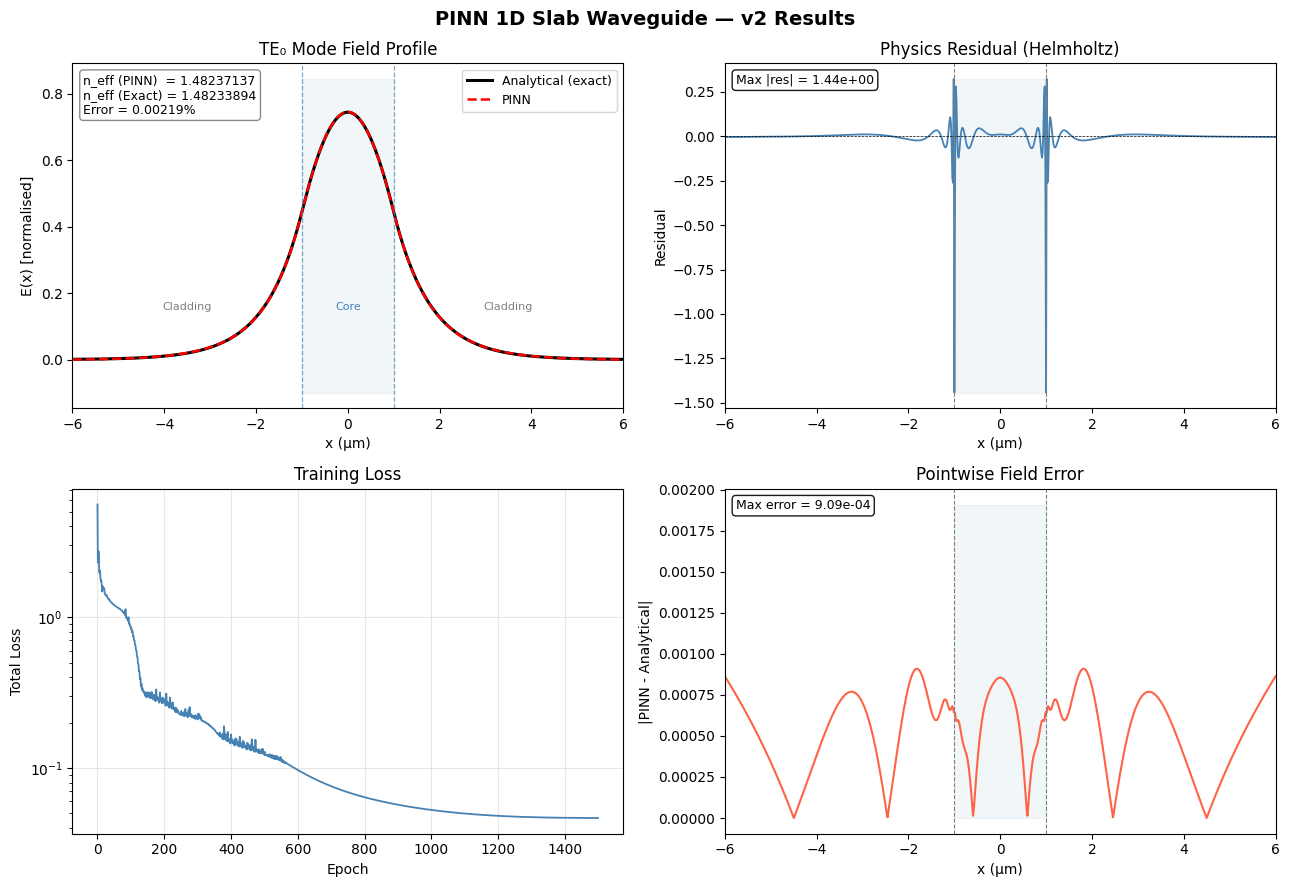

Saved: pinn_1d_results.png


In [ ]:
# ─────────────────────────────────────────────
# PLOTS
# ─────────────────────────────────────────────

x_plot = x_test_np.flatten()

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("PINN 1D Slab Waveguide — v2 Results", fontsize=14, fontweight='bold')

# Field profile
ax = axes[0, 0]
ax.plot(x_plot, E_anal, 'k-',  lw=2.2, label='Analytical (exact)')
ax.plot(x_plot, E_pred, 'r--', lw=1.8, label='PINN')
ax.axvline(-a, ls='--', color='steelblue', lw=0.9, alpha=0.7)
ax.axvline( a, ls='--', color='steelblue', lw=0.9, alpha=0.7)
ax.fill_betweenx([E_anal.min() - 0.1, E_anal.max() + 0.1], -a, a, alpha=0.07, color='steelblue')
ax.text( 0,   0.15, 'Core',     ha='center', fontsize=8, color='steelblue')
ax.text(-3.5, 0.15, 'Cladding', ha='center', fontsize=8, color='gray')
ax.text( 3.5, 0.15, 'Cladding', ha='center', fontsize=8, color='gray')
ax.text(0.02, 0.97,
        f"n_eff (PINN)  = {n_pinn:.8f}\nn_eff (Exact) = {n_anal:.8f}\nError = {error:.5f}%",
        transform=ax.transAxes, fontsize=9, va='top',
        bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.9))
ax.set_xlim(x_min, x_max)
ax.set_xlabel("x (µm)"); ax.set_ylabel("E(x) [normalised]")
ax.set_title("TE₀ Mode Field Profile"); ax.legend(fontsize=9)

# Physics residual
ax = axes[0, 1]
ax.plot(x_plot, res_np, color='steelblue', lw=1.3)
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.axvline(-a, ls='--', color='gray', lw=0.8)
ax.axvline( a, ls='--', color='gray', lw=0.8)
ax.fill_betweenx([res_np.min(), res_np.max()], -a, a, alpha=0.07, color='steelblue')
ax.text(0.02, 0.97, f"Max |res| = {np.max(np.abs(res_np)):.2e}",
        transform=ax.transAxes, fontsize=9, va='top',
        bbox=dict(boxstyle='round', fc='white', alpha=0.9))
ax.set_xlim(x_min, x_max)
ax.set_xlabel("x (µm)"); ax.set_ylabel("Residual")
ax.set_title("Physics Residual (Helmholtz)")

# Training loss
ax = axes[1, 0]
ax.plot(loss_hist, color='steelblue', lw=1.3)
ax.set_yscale('log')
ax.set_xlabel("Epoch"); ax.set_ylabel("Total Loss")
ax.set_title("Training Loss"); ax.grid(alpha=0.3)

# Pointwise field error
ax = axes[1, 1]
diff = np.abs(E_pred - E_anal)
ax.plot(x_plot, diff, color='tomato', lw=1.5)
ax.axvline(-a, ls='--', color='gray', lw=0.8)
ax.axvline( a, ls='--', color='gray', lw=0.8)
ax.fill_betweenx([0, diff.max() + 0.001], -a, a, alpha=0.07, color='steelblue')
ax.text(0.02, 0.97, f"Max error = {diff.max():.2e}",
        transform=ax.transAxes, fontsize=9, va='top',
        bbox=dict(boxstyle='round', fc='white', alpha=0.9))
ax.set_xlim(x_min, x_max)
ax.set_xlabel("x (µm)"); ax.set_ylabel("|PINN - Analytical|")
ax.set_title("Pointwise Field Error")

plt.tight_layout()
plt.savefig("pinn_1d_results.png", dpi=200, bbox_inches='tight')
plt.show()
print("Saved: pinn_1d_results.png")